In [1]:
import jax
import poppy
import functools

In [2]:
N = 2
p = 11
f = poppy.field(p)
th = poppy.theta(N,f)
print(th)

print('\nMEASUREMENTS')
for i in range(3):
  th = poppy.theta(N,f,seed=i) \
    .X(1) \
    .F(0) \
    .S(0,1) \
    .Q(0,4) \
    .Z(0,3) \
    .M([0,1,1])
  m = th.m[:th.t]
  print(f'{m}\n')

2 QUDIT STABILIZER STATE OVER FIELD 11

MEASUREMENTS
[[ 0 10]
 [ 1  0]
 [ 1  0]]

[[0 8]
 [1 9]
 [1 9]]

[[0 0]
 [1 1]
 [1 1]]



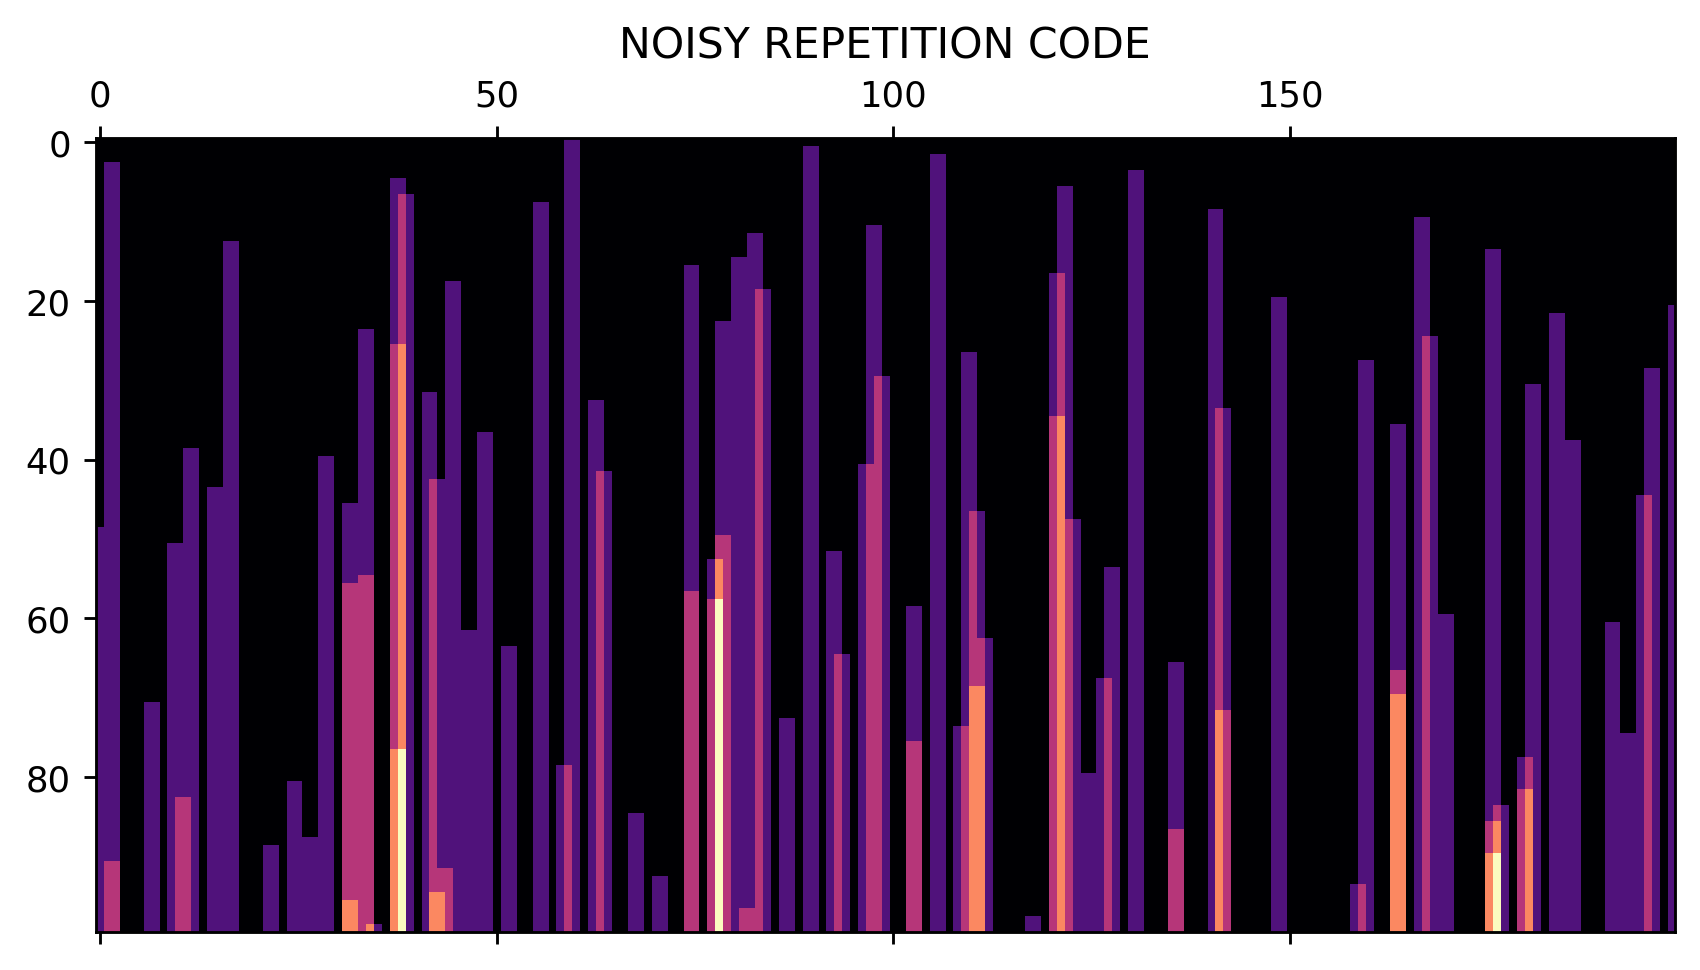

In [3]:
N = 200
p = 11
f = poppy.field(p)
th = poppy.theta(2*N-1,f)
I = jax.numpy.arange(2*N-1) # 2*N-1 qudits.
even = I[::2]               #   N   data.
odd = I[1::2]               #   N-1 checks.

def round(th,r):
  th = th.X(even[r])         # X a random even qudit.
  th = th.S(even[:-1],odd,1) # Entangle even and odd qudits.
  th = th.S(even[1: ],odd,1) # Entangle even and odd qudits.
  th = th.MR(odd)            # Measure and reset the odd qudits.
  return th,r

def repcode(th, rounds=N//2, seed=0):
  R = jax.random.randint(jax.random.key(seed), (rounds,), 0,N, dtype = poppy.DTYPE)
  th = jax.lax.scan(round,th,R)[0]
  return th

th = repcode(th)
m = th.m[:th.t,1].reshape(-1,N-1)
poppy.plot(m, title = 'NOISY REPETITION CODE', cmap = 'magma')

In [4]:
N = 100
p = 12421
f = poppy.field(p)
I = jax.numpy.arange(N)

@jax.jit
def random(seed=0):
  def R(i,n,s): return jax.random.choice(jax.random.key(s+i), I, (n,), replace = False)
  IFQ = jax.vmap(R, in_axes = (0,None,None))(I,2*(N//3),seed)
  IS  = jax.vmap(R, in_axes = (0,None,None))(I,2*(N//2),seed+N)
  IM  = jax.vmap(R, in_axes = (0,None,None))(I,   N//20,seed+N+N)
  RQ  = jax.random.randint(jax.random.key(seed),   (N,   N//3),   0,p, dtype = poppy.DTYPE)
  RM  = jax.random.randint(jax.random.key(seed+1), (N,2*(N//20)), 0,p, dtype = poppy.DTYPE)
  RR  = jax.random.randint(jax.random.key(seed+2), (2,   N),      0,p, dtype = poppy.DTYPE)
  return IFQ,IS,IM,RQ,RM,RR

@jax.jit
def layer(th,R):
  IFQ,IS,IM,RQ,RM = R
  th = th.F(IFQ[:N//3])          # N/3  Fourier gates
  th = th.Q(IFQ[N//3:],RQ)       # N/3  quadratic phase gates
  th = th.S(IS[:N//2],IS[N//2:]) # N/2  sum gates
  th = th.Z(IM,RM[:N//20])       # N/20 Z gates
  th = th.X(IM,RM[N//20:])       # N/20 X gates
  th = th.M(IM)                  # N/20 meausurements
  return th,i

@jax.jit
def circuit(th,R):
  th = jax.lax.scan(layer,th,R[:-1])[0] # N layers
  th = th.Z(I,R[-1][0])                 # N Z gates
  th = th.X(I,R[-1][1])                 # N X gates
  th = th.M(I)                          # N measurements
  return th

print(f'RANDOM {N} LAYER {N} QUDIT STABILIZER CIRCUIT OVER {f}')
R = random()
th = poppy.theta(N,f)
%timeit circuit(th,R).A.block_until_ready()
th = circuit(th,R)
m = th.m[:th.t]
print(f'\nMEASUREMENTS\n{m}')

RANDOM 100 LAYER 100 QUDIT STABILIZER CIRCUIT OVER FIELD 12421
217 ms ± 2.78 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MEASUREMENTS
[[   3 7579]
 [  39 8467]
 [  61 3381]
 ...
 [  97 3620]
 [  98 1706]
 [  99 8999]]
